## Laboratorio 1 de sistemas de control

### 1: Modelación del sistema

Se modeló el sistema dinámico con una ecuación del movimiento no lineal:

$$ \ddot\theta (t) = \frac{mlg}{2I_A} sin(\theta (t)) + \frac{C}{I_A} \dot\theta (t) $$

donde: 

$$ I_A = \frac{1}{4} m_{barra} R^2 + \frac{1}{3}m_{barra}  L^2$$

Creo que ahora está buena (?)

In [1]:
import numpy as np
from scipy.integrate import solve_ivp, odeint
import matplotlib.pyplot as plt

In [2]:
m_barra = 165e-3 # kg
m_soporte = (169.9 - 165)*10**-3 # kg

L = (25 * 25.4 + 17.7)*10**-3-0.0095 # m
d = 6.5e-3 # m
C = 0 # kgm^2
c_isma=0
g = 9.807 # m/s^2

I_A = 0.25*m_barra*(d/2)**2 + (1/3)*m_barra*L**2

In [3]:
print(2*(0.5*m_barra*L*g * I_A)**.5)

0.21763543808305832


In [4]:
def dThetadt(t, Y):
    y1, y2 = Y
    return [y2, -m_barra*L*g*np.sin(y1)/(2*I_A) - C/I_A*y2]

In [5]:
t = np.linspace(0,100,1000)

sol90 = odeint(dThetadt, y0=(-np.pi/2, 0), t=t, tfirst=True)

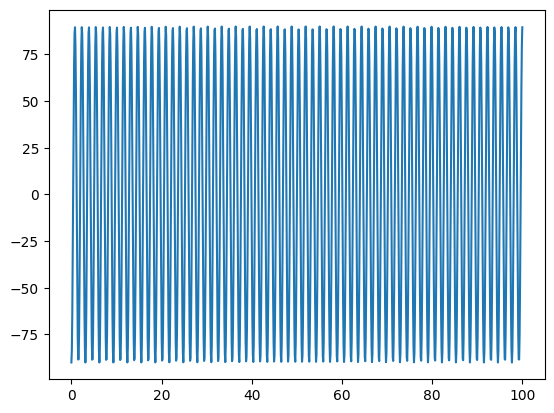

In [6]:
plt.plot(t, np.rad2deg(sol90.T[0]))

Ecuación de barra delgada simple.
$$\ddot \theta (t) = -\dot \theta (t) \cdot C \frac{3}{L} - sin(\theta(t)) \cdot \frac{g3}{2L}$$

In [7]:
def dThetadt_isma(t, Y):
    theta, dtheta = Y
    return [dtheta, -np.sin(theta)*(3*g)/(2*L) - c_isma*3/L*dtheta]

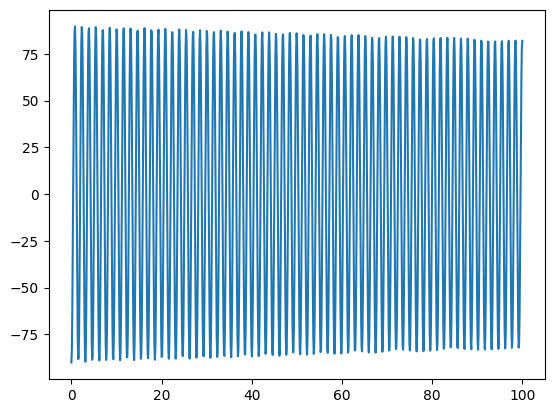

In [8]:
tiempo_inicio=0
tiempo_fin=100
t_otro=np.linspace(tiempo_inicio, tiempo_fin, 1000)
sol_isma90=solve_ivp(dThetadt_isma, t_span=[tiempo_inicio, tiempo_fin], y0=(-np.pi/2, 0), t_eval=t_otro)
# print(sol_isma90)
plt.plot(t_otro, np.rad2deg(sol_isma90.y[0]))

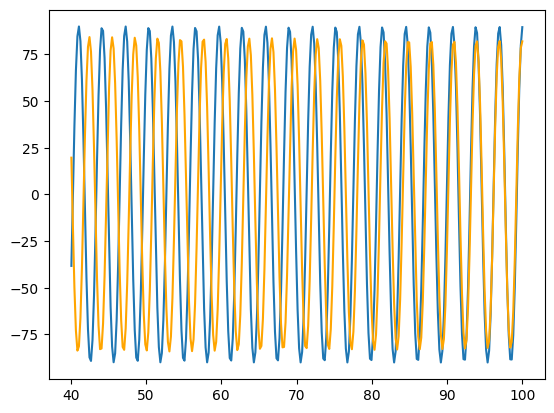

In [9]:
time_plot=np.linspace(0,100,500)[-300:]
plt.plot(time_plot, np.rad2deg(sol90.T[0])[-300:])
plt.plot(time_plot, np.rad2deg(sol_isma90.y[0])[-300:], color='orange')

### 2: Actividad experimental

#### Almacenamiento de datos

In [10]:
with open('g7_21.txt', 'r') as archivo:
    lineas21 = [line.rstrip() for line in archivo]
with open('g7_60.txt', 'r') as archivo:
    lineas60 = [line.rstrip() for line in archivo]
with open('g7_90.txt', 'r') as archivo:
    lineas90 = [line.rstrip() for line in archivo]


tiempo21, tiempo60, tiempo90 = [], [], []
theta21, theta60, theta90 = [], [], []

for i in lineas21[1:]:
    tiempo21.append(float(i.split(',')[0]))
    theta21.append(float(i.split(',')[1]))

for i in lineas60[1:]:
    tiempo60.append(float(i.split(',')[0]))
    theta60.append(float(i.split(',')[1]))

for i in lineas90[1:]:
    tiempo90.append(float(i.split(',')[0]))
    theta90.append(float(i.split(',')[1]))

#### Gráficos

Se configura la librería:

In [11]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8,6]

##### 21 Grados

In [12]:
máximos21 = []
segmento = []
# for i in range(len(tiempo21[880:])-2):
    # if True: print('yea')

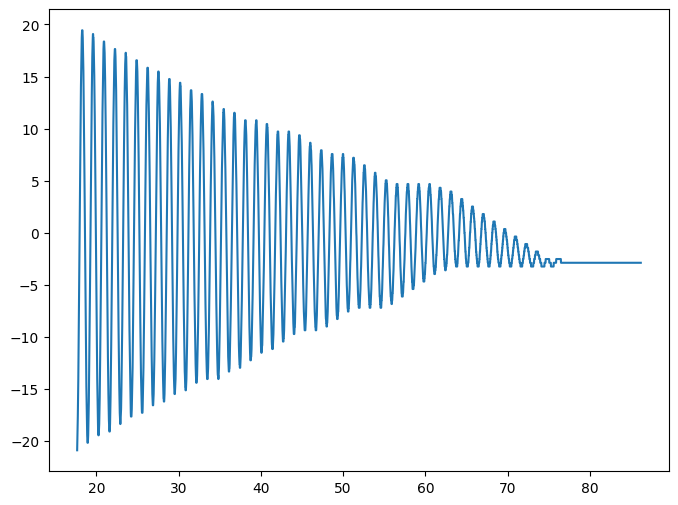

In [13]:
plt.plot(tiempo21[883:], theta21[883:])
# print(theta21[883])

##### 60 Grados

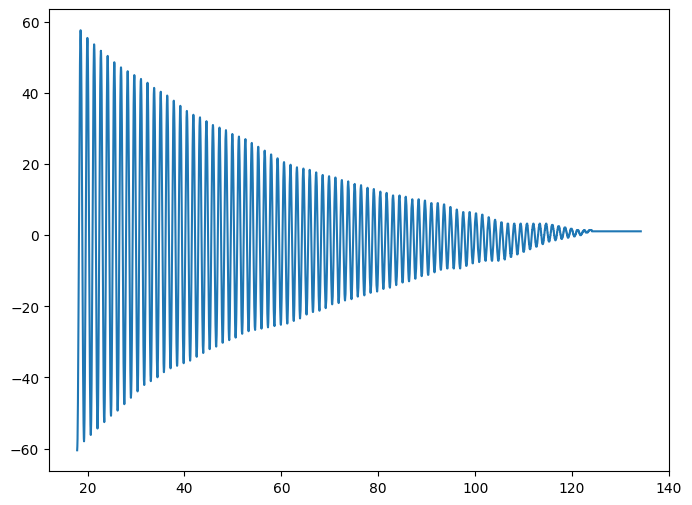

In [14]:
plt.plot(tiempo60[892:], theta60[892:])
# print(theta60[892])

##### 90 Grados

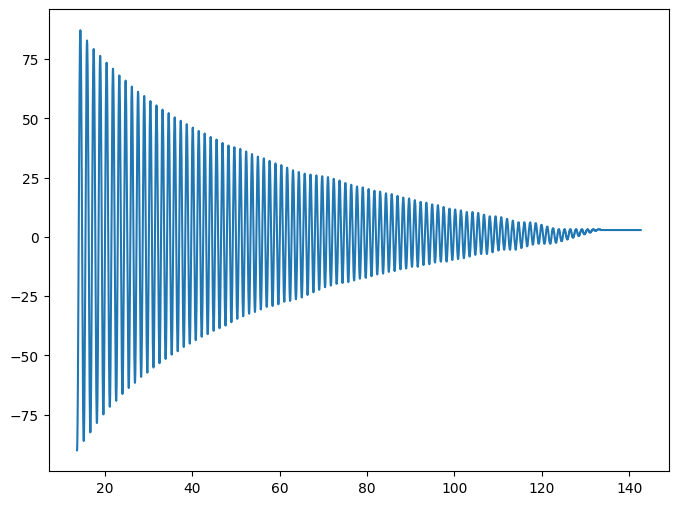

In [15]:
plt.plot(tiempo90[502:], theta90[502:])

Sea, al asumir una barra delgada un proporcional de amortiguación:
$$C=0.0095$$
obtenido al ojo.  
Y para el cilindro:
$$C=0.00106$$
obtenida al ojo también.

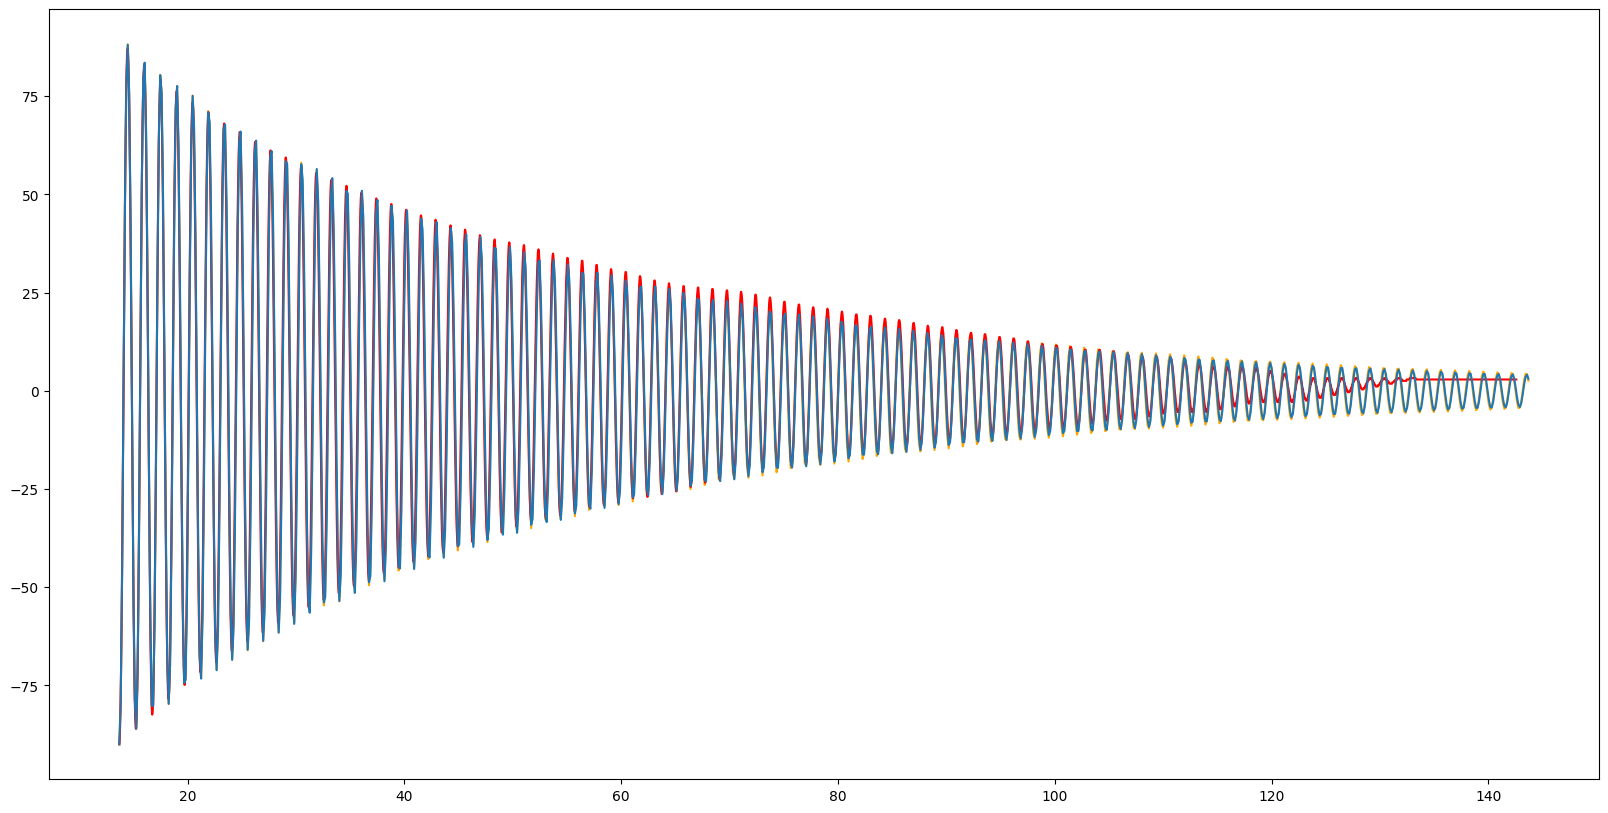

In [16]:
plt.rcParams['figure.figsize'] = [20,10]
C=0.00106
c_isma=0.00945
t_inicio=0
t_fin=130
t=np.linspace(t_inicio, t_fin, 1000)
sol90_martin = odeint(dThetadt, y0=(-np.pi/2, 0), t=t, tfirst=True)
sol90_isma=solve_ivp(dThetadt_isma,t_span=[t_inicio, t_fin], y0=(-np.pi/2, 0), t_eval=t)
print()
plt.plot([i+tiempo90[502]for i in t], np.rad2deg(sol90_isma.y[0]), color='orange')
plt.plot(tiempo90[502:], theta90[502:], color='red')
plt.plot([i+tiempo90[502]for i in t], np.rad2deg(sol90_martin.T[0]))

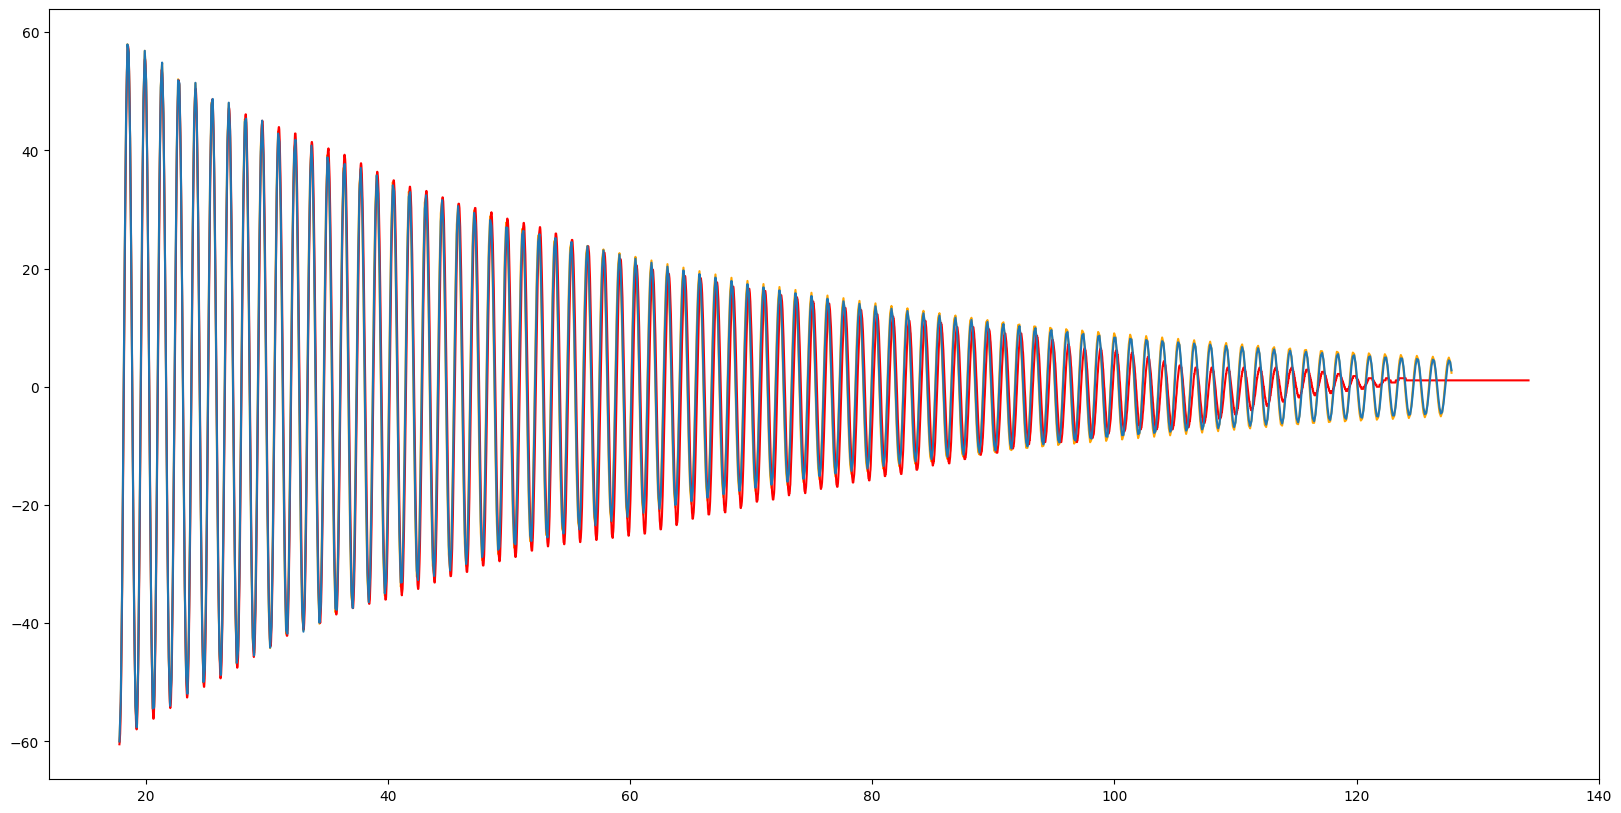

In [17]:
t_inicio=0
t_fin=110
t=np.linspace(t_inicio, t_fin, 1000)
sol60_martin = odeint(dThetadt, y0=(-np.deg2rad(60), 0), t=t, tfirst=True)
sol60_isma=solve_ivp(dThetadt_isma,t_span=[t_inicio, t_fin], y0=(-np.deg2rad(60), 0), t_eval=t)
print()
plt.plot([i+tiempo60[892]for i in t], np.rad2deg(sol60_isma.y[0]), color='orange')
plt.plot(tiempo60[892:], theta60[892:], color='red')
plt.plot([i+tiempo60[892]for i in t], np.rad2deg(sol60_martin.T[0]))

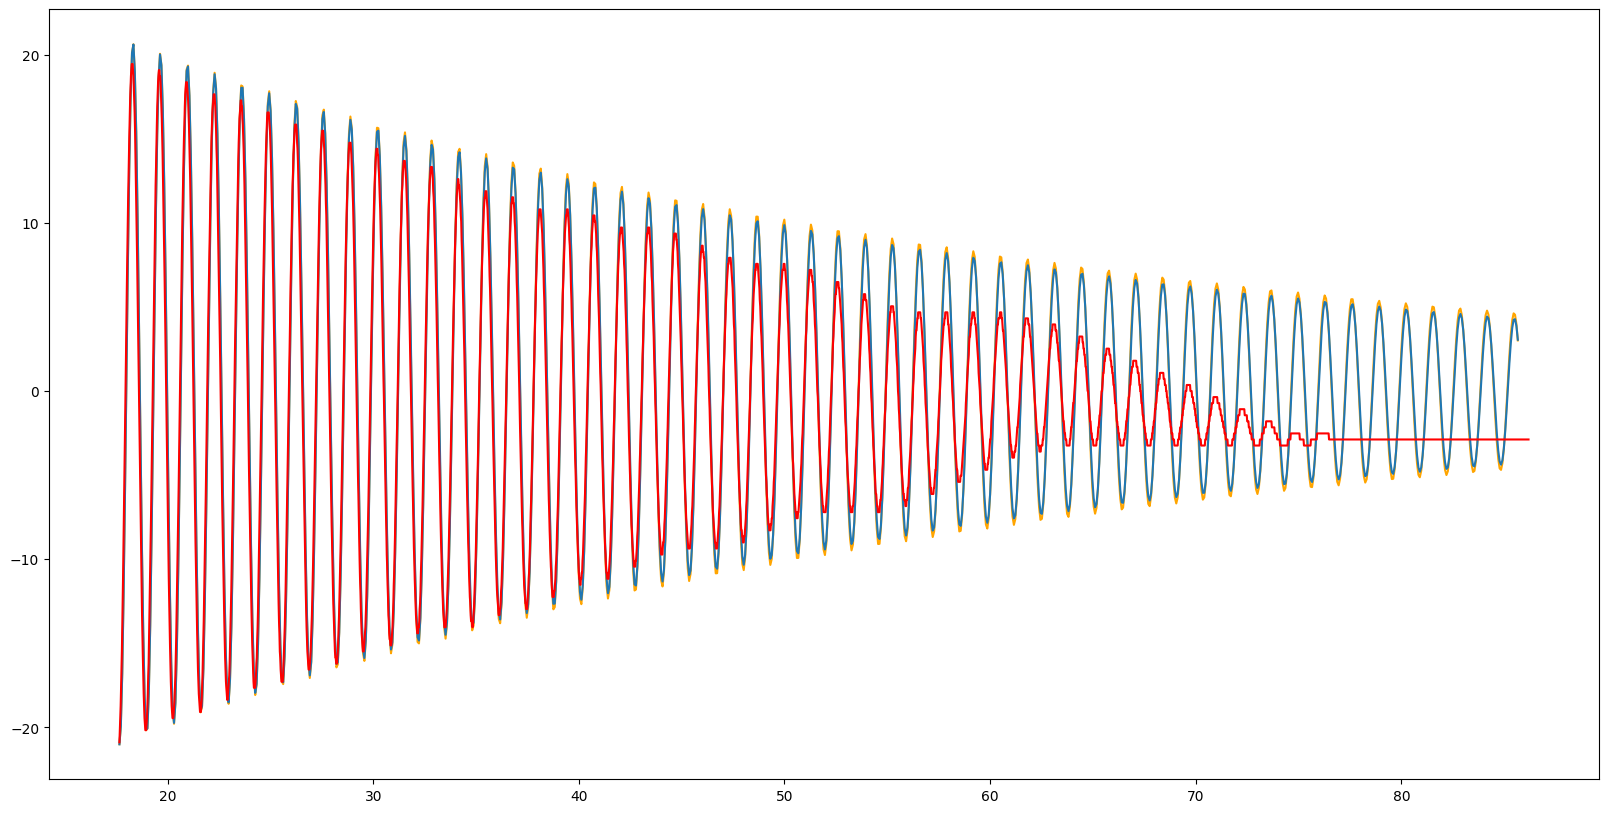

In [18]:
t_inicio=0
t_fin=68
t=np.linspace(t_inicio, t_fin, 1000)
sol21_martin = odeint(dThetadt, y0=(-np.deg2rad(21), 0), t=t, tfirst=True)
sol21_isma=solve_ivp(dThetadt_isma,t_span=[t_inicio, t_fin], y0=(-np.deg2rad(21), 0), t_eval=t)
print()
plt.plot([i+tiempo21[883]for i in t], np.rad2deg(sol21_isma.y[0]), color='orange')

plt.plot([i+tiempo21[883]for i in t], np.rad2deg(sol21_martin.T[0]))
plt.plot(tiempo21[883:], theta21[883:], color='red')